<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/Customer_Segmentation_using_KMeans_Clustring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#MAchine Learning related classes and function
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score



In [3]:
customer = pd.read_csv("/content/Mall_Customers (1).csv")

In [4]:
customer.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
#print the number of row and columns in the dataframe
customer.shape


(200, 5)

In [6]:
customer.drop(columns="CustomerID",inplace=True)
#customer.drop("CustomerID",axis = 1,inplace=True)

In [7]:
customer.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [8]:
customer.isnull().sum(axis=0)
# prints the total number of missing values column wise

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [9]:
customer.isnull().sum(axis=1)
#print the row wise which have more then 1 missing value


,0
0,0
1,0
2,0
3,0
4,0
...,...
195,0
196,0
197,0
198,0


In [10]:
customer = customer[customer.isnull().sum(axis=1)<=1]
#keep the row which have maximum of missing values and remove the rest

In [11]:
#checking for duplicate
customer.duplicated().sum()

np.int64(0)

In [12]:
customer.drop_duplicates(inplace=True)
#Drop all the duplicate row

In [13]:
customer.dtypes

,0
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [14]:
#Encoding the Gender Column

In [15]:
le = LabelEncoder()
customer['Gender'] = le.fit_transform(customer['Gender'])

** Feature Engineering**

***
1.Outliers

2.Creating new features

3.Standardization or Normilization
(Scaling of the data)

4.Encoding of the features

5.Binning of the features
***

3.Machine Learning Process

In [16]:
customer.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [17]:
x = customer.iloc[:,2:4].values

In [18]:
x[0:10]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40],
       [17, 76],
       [18,  6],
       [18, 94],
       [19,  3],
       [19, 72]])

***Standardization of the data***

In [19]:
scaler = StandardScaler()
x =scaler.fit_transform(x)

In [20]:
x

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

***Finding Optimal K***

K-Means requires us to specify the number of clusters (k) upfront. We'll use three methods to identify the best k:

1. **WCSS or ELbow Methods:** look at how much inertia decreses as K grows

2.**Silhouette Score:** measures how well-separated the clusters are

3.**Davies-Bouldin Index:** measures cluster compactness vs separation
We test k=2 through 10 for all three methods.

**a.ECSS Methods or Elbow Methods**

**WCSS=** The sum of squared distance of each point to its cluster centroidd,within a cluster.Also known as Inertia.
 .Lower inertia=tighter cluster(but adding K always reduces inertia)

  .Look for the "Elbow" point,the point where inertia stop dropping sharply
   .Beyond the elbow point,adding more clusters gives diminishing returns

In [22]:
wcss=[]
for k in range(2,11):
  kmeans = KMeans(n_clusters=k,n_init=10,random_state=42)
  kmeans.fit(x)
  #the traning starts

  print(kmeans.inertia_)
  wcss.append(kmeans.inertia_)

269.69101219276405
157.70400815035939
108.92131661364358
65.56840815571681
55.057348270385965
44.86475569922555
37.22818767758587
32.39226763033118
29.981897788243703


***Plot wcss and corresponding k***

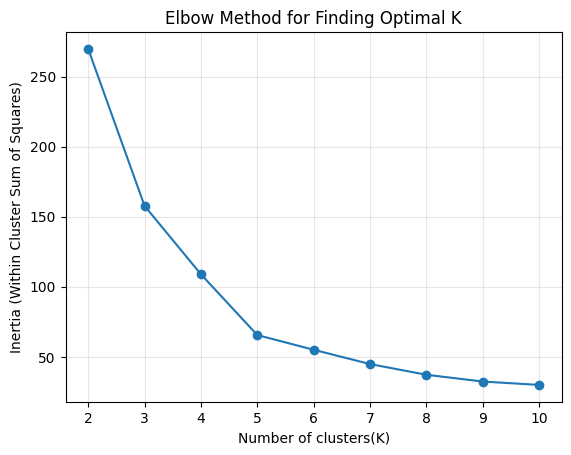

In [24]:
plt.plot(range(2,11),wcss,marker='o')
plt.xlabel("Number of clusters(K)")
plt.ylabel("Inertia (Within Cluster Sum of Squares)")
plt.title("Elbow Method for Finding Optimal K")
plt.xticks(range(2,11))
plt.grid(True,alpha=0.3)
plt.show()

**b.Silhouette Score**
The Silhoutte Score measures how well each point ffits its assigned cluster compared to other clusters.

**.Range:-**-1 to 1

**.Higher is better**a score near 1 means 1 means cluster are well-separated and compact

**.**A Score near 0 means cluster overlap negative means points may be mis clustered

In [26]:
silhouette_scores=[]
for i in range(2,11):
  kmeans = KMeans(n_clusters=i,n_init=10,random_state=42)
  labels=kmeans.fit_predict(x)
  score = silhouette_score(x,labels)
  silhouette_scores.append(score)

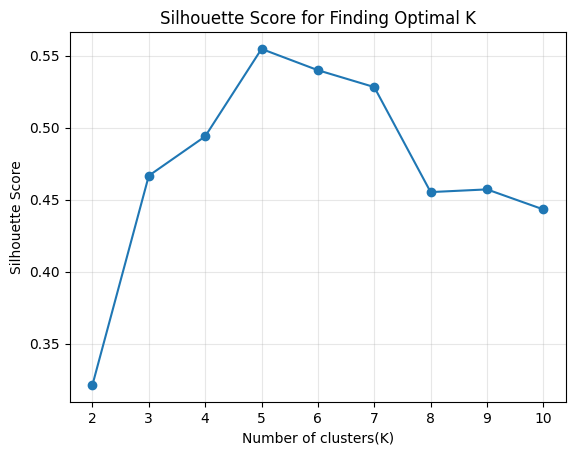

AttributeError: 'function' object has no attribute 'index'

In [27]:
plt.plot(range(2,11),silhouette_scores,marker='o')
plt.xlabel("Number of clusters(K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Finding Optimal K")
plt.xticks(range(2,11))
plt.grid(True,alpha=0.3)
plt.show()

best_k_silhouette = list(range(2,11))[silhouette_score.index(max(silhouette_scores))]
print(f"Best K based on Silhouette Score:{best_k_silhouette}(score:{max(silhouette_scores):.4f})")

**c.Davies-Bouldin Index(DBI)**

THe Davies-Bouldin index measures the ration of within-cluster scatter to between-cluster seperation

**Lower is Better:** compact well-separted clusters score near 0.

In [31]:
dbi_score = []
for  k in range(2,11):
  kmeans = KMeans(n_clusters=k,n_init=10,random_state=42)
  labels = kmeans.fit_predict(x)
  score = davies_bouldin_score(x,labels)
  dbi_score.append(score)


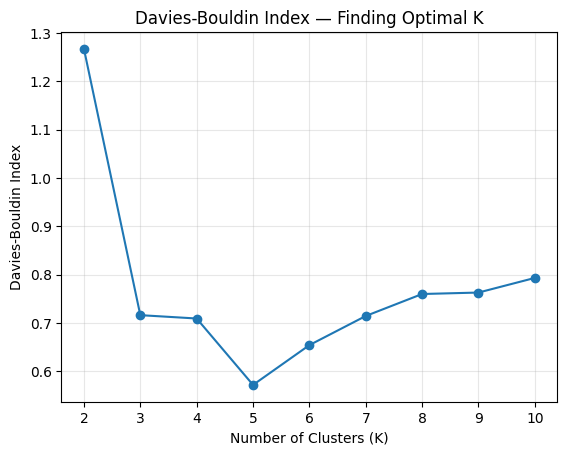

NameError: name 'dbi_scores' is not defined

In [32]:
plt.plot(range(2, 11), dbi_score, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index — Finding Optimal K')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

best_k_dbi = list(range(2,11))[dbi_score.index(min(dbi_score))]
print(f"Best K by Davies-Bouldin Index: {best_k_dbi} (score: {min(dbi_scores):.4f})")

**Apply KMeans Clustring on the data**

In [34]:
kmeans_final = KMeans(n_clusters=5,n_init=10,random_state=42)
kmeans_final.fit(x)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [36]:
y = kmeans_final.fit_predict(x)

In [37]:
y

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [38]:
output = pd.DataFrame(y,columns = ["Cluster Number"])

In [39]:
final_df = pd.concat([customer,output],axis = 1)

In [40]:
final_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster Number
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4


**Visualize the clusters**

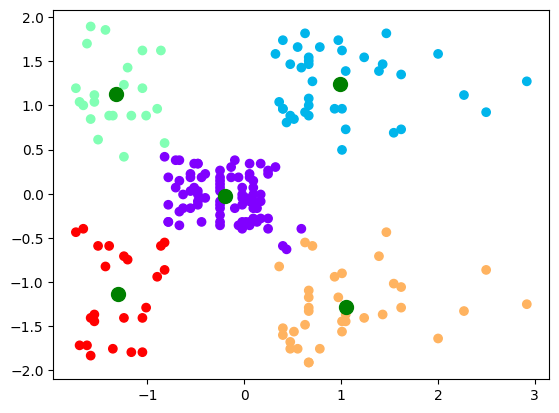

In [41]:
plt.scatter(x[:,0],x[:,1],c=y,cmap='rainbow')
plt.scatter(kmeans_final.cluster_centers_[:,0],kmeans_final.cluster_centers_[:,1],s=100,c='green')
plt.show()